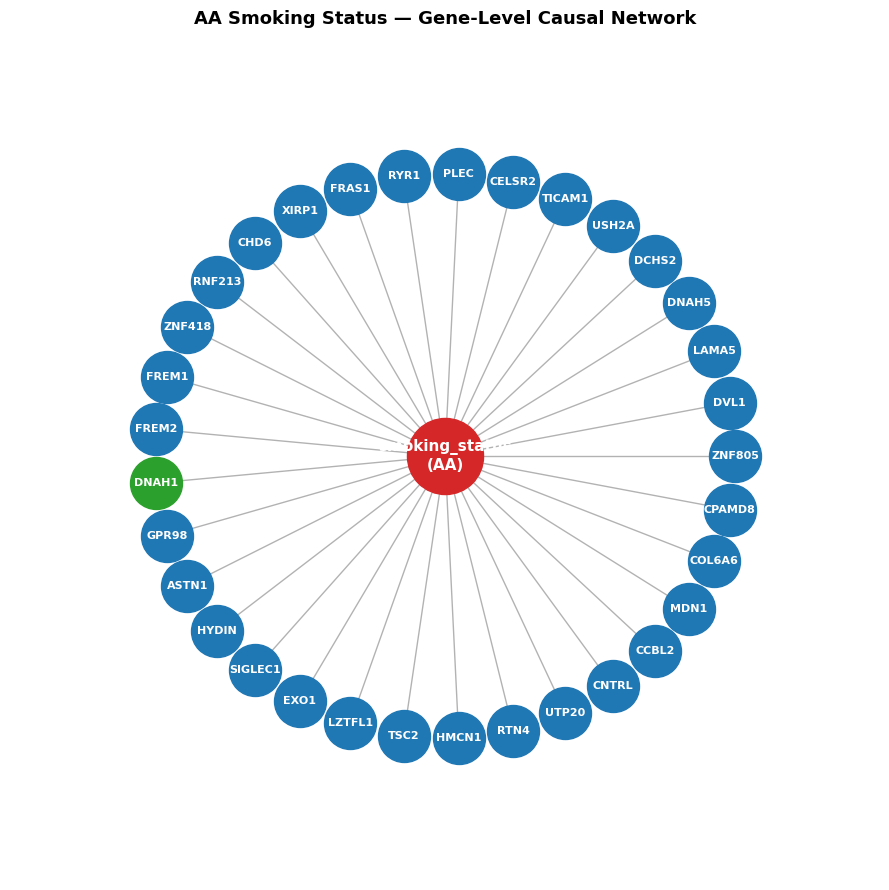

Saved: C:\Users\user\Downloads\GSE148375_clean\sunflower_gene_smoking_AA.png


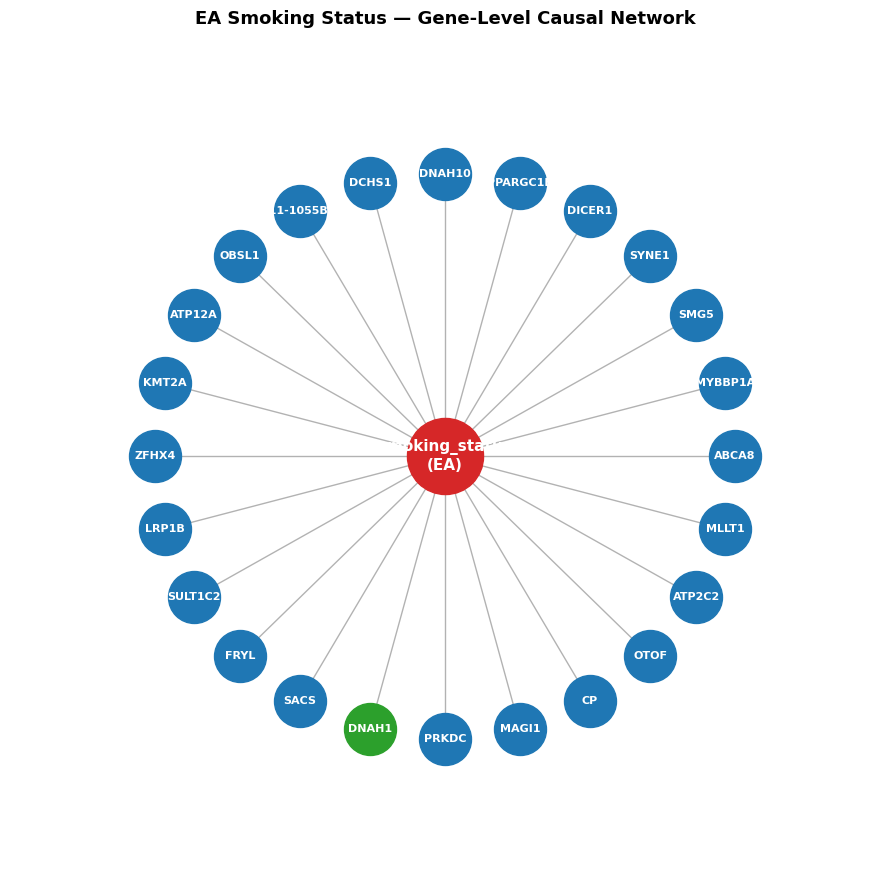

Saved: C:\Users\user\Downloads\GSE148812_clean\sunflower_gene_smoking_EA.png


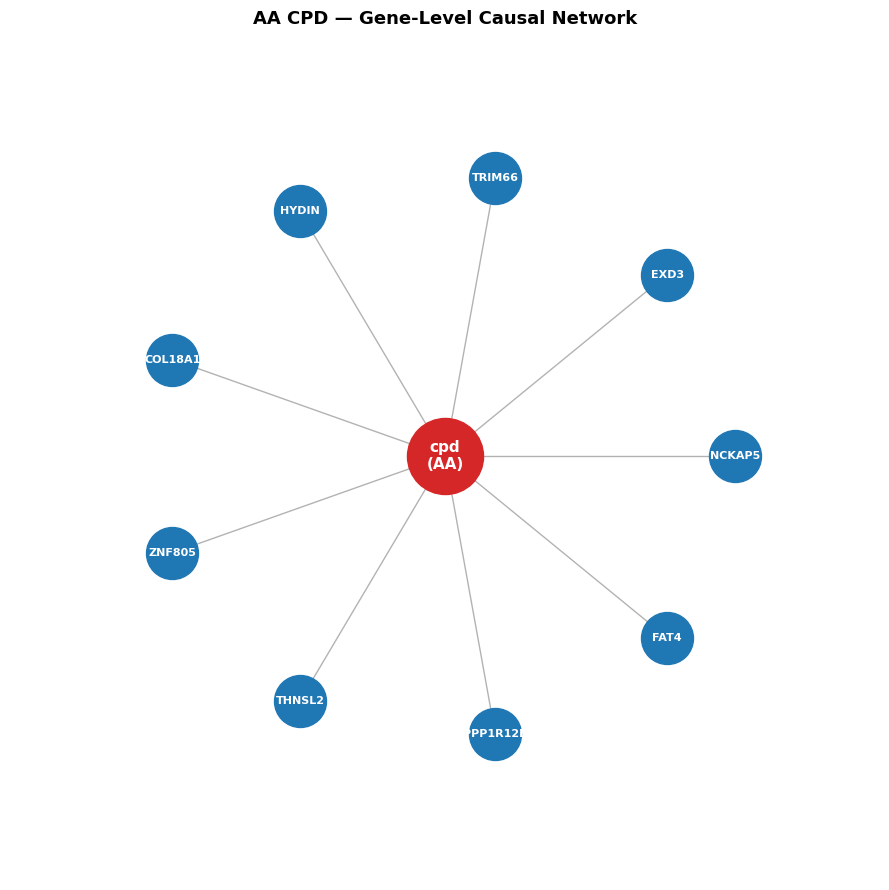

Saved: C:\Users\user\Downloads\GSE148375_clean\sunflower_gene_cpd_AA.png


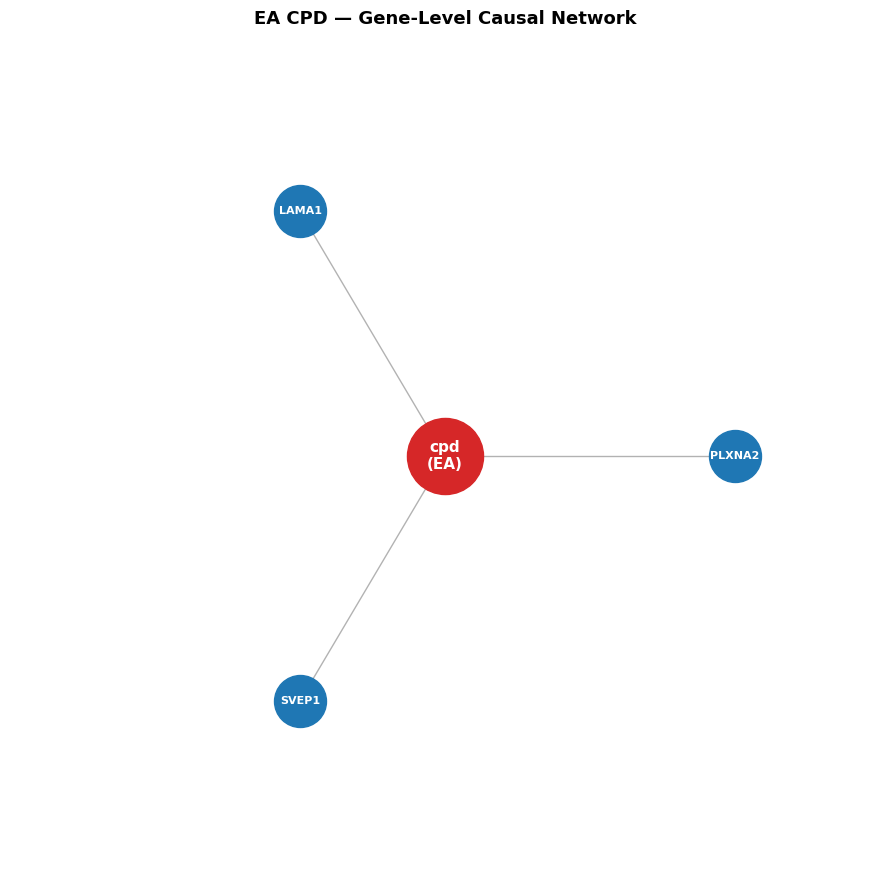

Saved: C:\Users\user\Downloads\GSE148812_clean\sunflower_gene_cpd_EA.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

def sunflower_plot(center_label, direct_parents, title, save_path, highlight_genes=None):
    highlight_genes = highlight_genes or []
    n = len(direct_parents)
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axis('off')

    # Center node
    ax.scatter([0], [0], s=3000, color='#d62728', zorder=3)
    ax.text(0, 0, center_label, ha='center', va='center', fontsize=11,
             fontweight='bold', color='white', zorder=4)

    # Direct parent ring
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    radius = 1.0
    for angle, gene in zip(angles, direct_parents):
        x, y = radius*np.cos(angle), radius*np.sin(angle)
        ax.plot([0, x], [0, y], color='gray', linewidth=1, zorder=1, alpha=0.6)
        color = '#2ca02c' if gene in highlight_genes else '#1f77b4'
        ax.scatter([x], [y], s=1400, color=color, zorder=2)
        ax.text(x, y, gene, ha='center', va='center', fontsize=8,
                 fontweight='bold', color='white', zorder=4)

    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

aa_dir = r"C:\Users\user\Downloads\GSE148375_clean"
ea_dir = r"C:\Users\user\Downloads\GSE148812_clean"

# AA Smoking (33 genes, validated 2-group split)
aa_smoking_parents = ['ZNF805', 'DVL1', 'LAMA5', 'DNAH5', 'DCHS2', 'USH2A', 'TICAM1', 'CELSR2', 
                       'PLEC', 'RYR1', 'FRAS1', 'XIRP1', 'CHD6', 'RNF213', 'ZNF418', 'FREM1',
                       'FREM2', 'DNAH1', 'GPR98', 'ASTN1', 'HYDIN', 'SIGLEC1', 'EXO1', 'LZTFL1', 
                       'TSC2', 'HMCN1', 'RTN4', 'UTP20', 'CNTRL', 'CCBL2', 'MDN1', 'COL6A6', 'CPAMD8']
sunflower_plot("smoking_status\n(AA)", aa_smoking_parents,
               "AA Smoking Status — Gene-Level Causal Network",
               os.path.join(aa_dir, "sunflower_gene_smoking_AA.png"),
               highlight_genes=['DNAH1'])

# EA Smoking (24 genes, validated 2-group split)
ea_smoking_parents = ['ABCA8', 'MYBBP1A', 'SMG5', 'SYNE1', 'DICER1', 'PPARGC1B', 'DNAH10', 'DCHS1', 
                       'RP11-1055B8.7', 'OBSL1', 'ATP12A', 'KMT2A', 'ZFHX4', 'LRP1B', 'SULT1C2', 
                       'FRYL', 'SACS', 'DNAH1', 'PRKDC', 'MAGI1', 'CP', 'OTOF', 'ATP2C2', 'MLLT1']
sunflower_plot("smoking_status\n(EA)", ea_smoking_parents,
               "EA Smoking Status — Gene-Level Causal Network",
               os.path.join(ea_dir, "sunflower_gene_smoking_EA.png"),
               highlight_genes=['DNAH1'])

# AA CPD (9 genes, direct PC)
aa_cpd_parents = ['NCKAP5', 'EXD3', 'TRIM66', 'HYDIN', 'COL18A1', 'ZNF805', 'THNSL2', 'PPP1R12B', 'FAT4']
sunflower_plot("cpd\n(AA)", aa_cpd_parents,
               "AA CPD — Gene-Level Causal Network",
               os.path.join(aa_dir, "sunflower_gene_cpd_AA.png"))

# EA CPD (3 genes, direct PC)
ea_cpd_parents = ['PLXNA2', 'LAMA1', 'SVEP1']
sunflower_plot("cpd\n(EA)", ea_cpd_parents,
               "EA CPD — Gene-Level Causal Network",
               os.path.join(ea_dir, "sunflower_gene_cpd_EA.png"))